In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xlrd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
# from xgboost import XGBClassifier

In [3]:
# git clone git@github.com:Joel-HECI/IABO.git

In [4]:



wb=pd.read_excel("IABO/mfcc_features_avg.xlsx",header=0)
a1 = np.array(wb.mfcc_1)
a2=np.array(wb.mfcc_2)
a3=np.array(wb.mfcc_3)
a4=np.array(wb.mfcc_4)
a5=np.array(wb.mfcc_5)
a6=np.array(wb.mfcc_6)
a7=np.array(wb.mfcc_7)
a8=np.array(wb.mfcc_8)
a9=np.array(wb.mfcc_9)
a10=np.array(wb.mfcc_10)
a11=np.array(wb.mfcc_11)
a12=np.array(wb.mfcc_12)
a13=np.array(wb.mfcc_13)

clases=np.array(wb.label)

print(clases)

['LEFT' 'LEFT' 'LEFT' 'LEFT' 'LEFT' 'LEFT' 'LEFT' 'LEFT' 'LEFT' 'LEFT'
 'RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'RIGHT'
 'RIGHT' 'UP' 'UP' 'UP' 'UP' 'UP' 'UP' 'UP' 'UP' 'UP' 'UP' 'DOWN' 'DOWN'
 'DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']


In [5]:
X = np.array([a1,a2,a3,a4,a5,a6,a7,a8,a9,a10,a11,a12,a13])
X = X.transpose()

X_train,X_test,Y_train,Y_test = train_test_split(X,clases,test_size=0.3)

In [6]:
le = LabelEncoder()
Y_train_numeric = le.fit_transform(Y_train)
print(Y_train_numeric)

[1 2 1 3 3 2 0 1 1 2 2 0 3 0 1 1 1 0 3 2 1 0 1 1 3 2 2 0]


Text(0, 0.5, 'MFCC 3')

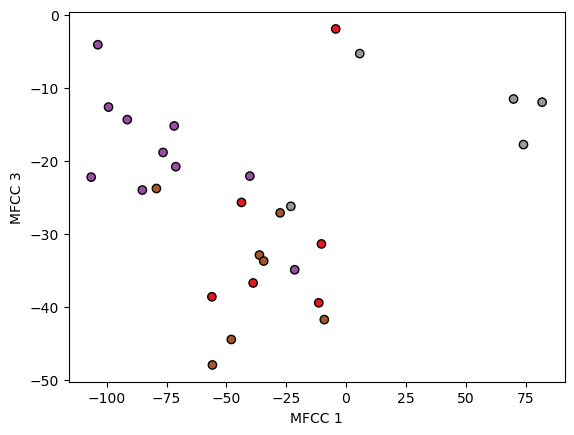

In [7]:
plt.scatter(X_train[:, 0], X_train[:, 2], c=Y_train_numeric, cmap=plt.cm.Set1, edgecolor='k')
plt.xlabel('MFCC 1')
plt.ylabel('MFCC 3')

In [8]:
# Plot every possible combination of MFCC features (scatter plots), each in a separate figure
import itertools

mfcc_indices = list(range(X_train.shape[1]))
combinations = list(itertools.combinations(mfcc_indices, 2))

# for i, j in combinations:
#     plt.figure(figsize=(6, 5))
#     plt.scatter(X_train[:, i], X_train[:, j], c=Y_train_numeric, cmap=plt.cm.Set1, edgecolor='k')
#     plt.xlabel(f'MFCC {i+1}')
#     plt.ylabel(f'MFCC {j+1}')
#     plt.title(f'MFCC {i+1} vs MFCC {j+1}')
#     plt.tight_layout()
#     plt.show()

In [9]:
# Clasificador KNN
clasificador_KNN = KNeighborsClassifier(n_neighbors=7)
clasificador_KNN.fit(X_train,Y_train)

# Clasificador Regresión Logística
clasificador_LR=LogisticRegression()
clasificador_LR.fit(X_train,Y_train)

# Clasificador Naive Bayes Gaussiano
clasificador_NBG=gnb = GaussianNB()
clasificador_NBG.fit(X_train,Y_train)

# Clasificador Arbol de decisión
clasificador_DT=DecisionTreeClassifier()
clasificador_DT.fit(X_train,Y_train)

# Clasificador Random Forest
clasificador_RF = RandomForestClassifier()
clasificador_RF.fit(X_train,Y_train)

# Clasificador Máquina de Soporte Vectoria
clasificador_SVM=svm.SVC()
clasificador_SVM.fit(X_test,Y_test)

# Clasificador Perceptron Multicapa
clasificador_MLP=MLPClassifier(alpha =1e5,hidden_layer_sizes=[16,32],max_iter=100)
clasificador_MLP.fit(X_test,Y_test)

# XKBoost
# model = XGBClassifier()
# model.fit(x_train, y_train)

/usr/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","[16, 32]"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",100000.0
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


In [10]:
# Evaluación KNN
clasificacion= clasificador_KNN.predict(X_test)
mat_con=confusion_matrix(Y_test,clasificacion)
print("KNN : ",accuracy_score(Y_test,clasificacion))

# Evaluación KNN
clasificacion= clasificador_LR.predict(X_test)
mat_con=confusion_matrix(Y_test,clasificacion)
print("LR : ",accuracy_score(Y_test,clasificacion))

# Evaluación NBG
clasificacion= clasificador_NBG.predict(X_test)
mat_con=confusion_matrix(Y_test,clasificacion)
print("NBG : ",accuracy_score(Y_test,clasificacion))

# Evaluación DT
clasificacion= clasificador_DT.predict(X_test)
mat_con=confusion_matrix(Y_test,clasificacion)
print("DT : ",accuracy_score(Y_test,clasificacion))

# Evaluación RF
clasificacion= clasificador_RF.predict(X_test)
mat_con=confusion_matrix(Y_test,clasificacion)
print("RF : ",accuracy_score(Y_test,clasificacion))

# Evaluación SVM
clasificacion= clasificador_SVM.predict(X_test)
mat_con=confusion_matrix(Y_test,clasificacion)
print("SVM : ",accuracy_score(Y_test,clasificacion))

# Evaluación MLP
clasificacion= clasificador_MLP.predict(X_test)
mat_con=confusion_matrix(Y_test,clasificacion)
print("MLP : ",accuracy_score(Y_test,clasificacion))

# # evaluación XGBoost
# clasificacion= model.predict(x_test)
# mat_con=confusion_matrix(y_test,clasificacion)
# print("XGBoost : ",accuracy_score(y_test,clasificacion))

KNN :  0.5833333333333334
LR :  0.75
NBG :  0.9166666666666666
DT :  0.4166666666666667
RF :  0.75
SVM :  0.5833333333333334
MLP :  0.4166666666666667


In [11]:
values = np.array([
    -333.200531005859,
    156.244873046875,
    -3.12946510314941,
    26.5577449798584,
    -18.5709686279297,
    21.7374649047852,
    0.301054149866104,
    14.5875282287598,
    19.1146221160889,
    -17.5485591888428,
    -5.49166631698608,
    6.72605752944946,
    -5.08723878860474
], dtype=float)

res = clasificador_LR.predict(values.reshape(1, -1))
print(res)

['RIGHT']


In [12]:
# Calculate mean and standard deviation for each MFCC feature per class
classes = np.unique(clases)
curves = []
for cls in classes:
    mask = clases == cls
    print(f"\n{'='*50}")
    print(f"Class: {cls}")
    print(f"{'='*50}")
    
    for i in range(1, 14):
        feature = eval(f'a{i}')[mask]
        mean = np.mean(feature)
        std = np.std(feature)
        curves.append((i, cls,mean, std))
        print(f"MFCC {i:2d} - Mean: {mean:10.4f} | Std Dev: {std:10.4f}")


Class: DOWN
MFCC  1 - Mean:   -40.6734 | Std Dev:    25.0614
MFCC  2 - Mean:   135.9332 | Std Dev:    18.2522
MFCC  3 - Mean:   -28.2151 | Std Dev:    10.6397
MFCC  4 - Mean:    26.9785 | Std Dev:     8.8080
MFCC  5 - Mean:    -3.6868 | Std Dev:     7.9792
MFCC  6 - Mean:   -12.6927 | Std Dev:     7.0255
MFCC  7 - Mean:     2.4941 | Std Dev:     6.6692
MFCC  8 - Mean:   -12.4021 | Std Dev:     5.9125
MFCC  9 - Mean:    11.5386 | Std Dev:     5.0207
MFCC 10 - Mean:     3.0489 | Std Dev:     3.1086
MFCC 11 - Mean:    -9.5859 | Std Dev:     4.3606
MFCC 12 - Mean:    -3.9599 | Std Dev:     2.6267
MFCC 13 - Mean:    -4.6441 | Std Dev:     3.2935

Class: LEFT
MFCC  1 - Mean:   -76.7022 | Std Dev:    26.1728
MFCC  2 - Mean:   110.7076 | Std Dev:    12.6629
MFCC  3 - Mean:   -18.8834 | Std Dev:     7.7382
MFCC  4 - Mean:    21.5993 | Std Dev:     3.9666
MFCC  5 - Mean:     4.7300 | Std Dev:     3.1387
MFCC  6 - Mean:   -20.0911 | Std Dev:     4.3677
MFCC  7 - Mean:     0.6008 | Std Dev:     4

In [13]:

print(curves)

[(1, 'DOWN', np.float64(-40.67342472076416), np.float64(25.061414453128855)), (2, 'DOWN', np.float64(135.93318557739258), np.float64(18.25217038778347)), (3, 'DOWN', np.float64(-28.215061795711517), np.float64(10.639748864460513)), (4, 'DOWN', np.float64(26.978494811058045), np.float64(8.80799927365468)), (5, 'DOWN', np.float64(-3.6867693185806276), np.float64(7.979236825350776)), (6, 'DOWN', np.float64(-12.692676162719726), np.float64(7.025539020551757)), (7, 'DOWN', np.float64(2.494067430496216), np.float64(6.66924145814875)), (8, 'DOWN', np.float64(-12.402070546150208), np.float64(5.912450807599079)), (9, 'DOWN', np.float64(11.538572478294373), np.float64(5.020731944746862)), (10, 'DOWN', np.float64(3.048911917209625), np.float64(3.1085571006054855)), (11, 'DOWN', np.float64(-9.585856413841247), np.float64(4.360556826701356)), (12, 'DOWN', np.float64(-3.959913945198059), np.float64(2.626667922616889)), (13, 'DOWN', np.float64(-4.644112491607666), np.float64(3.2935327147604205)), (1,

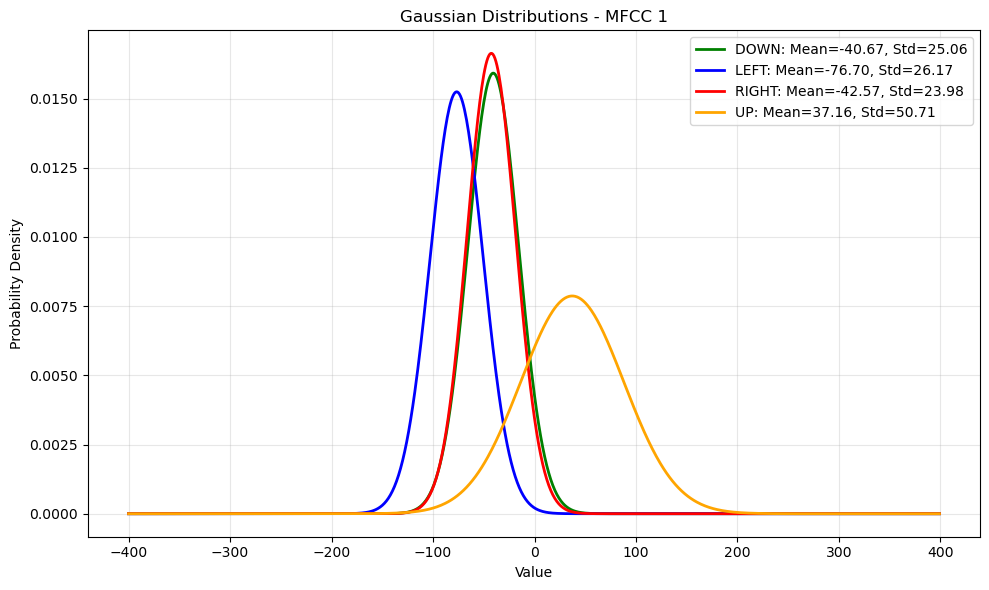

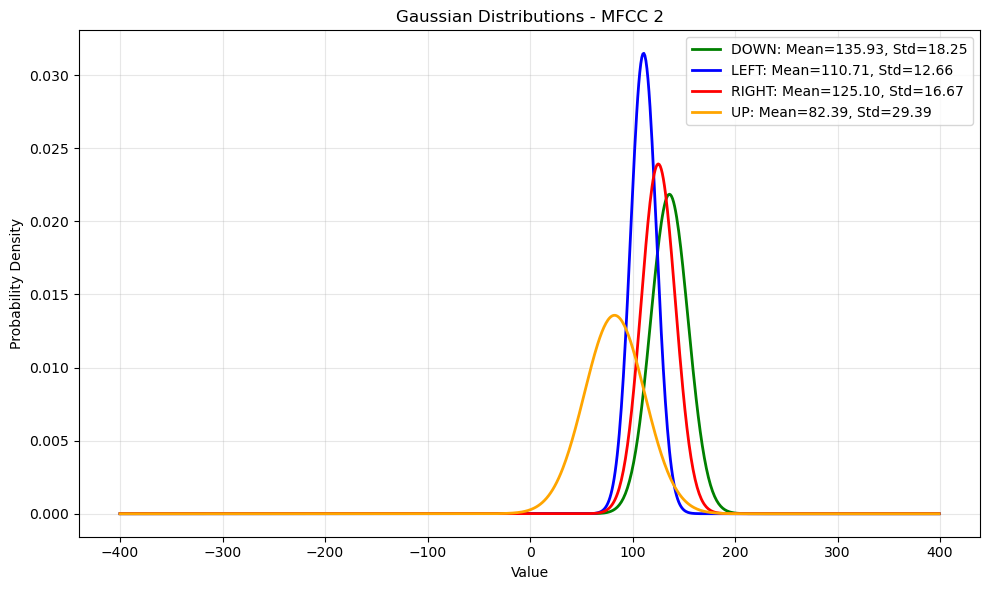

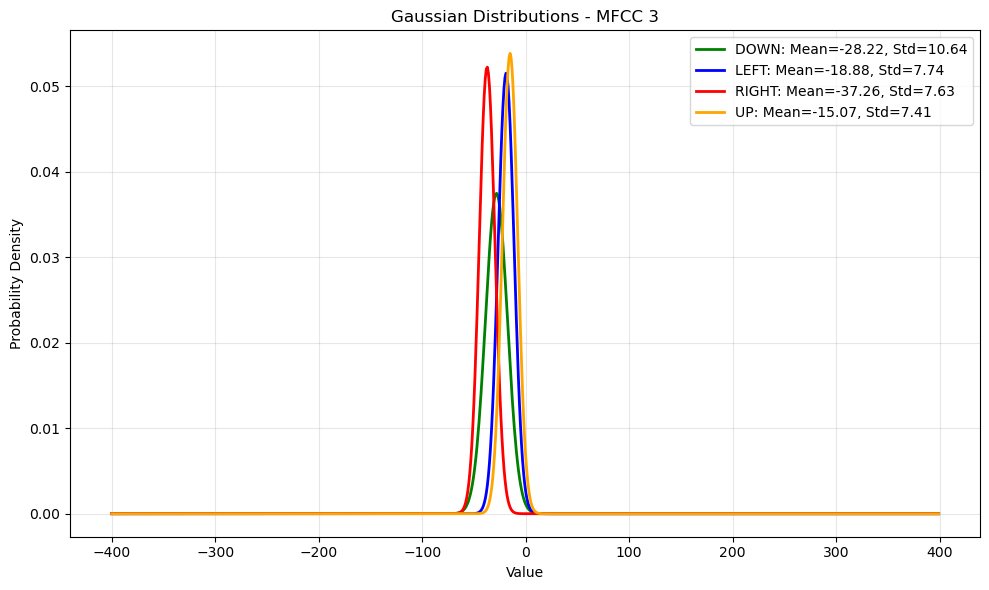

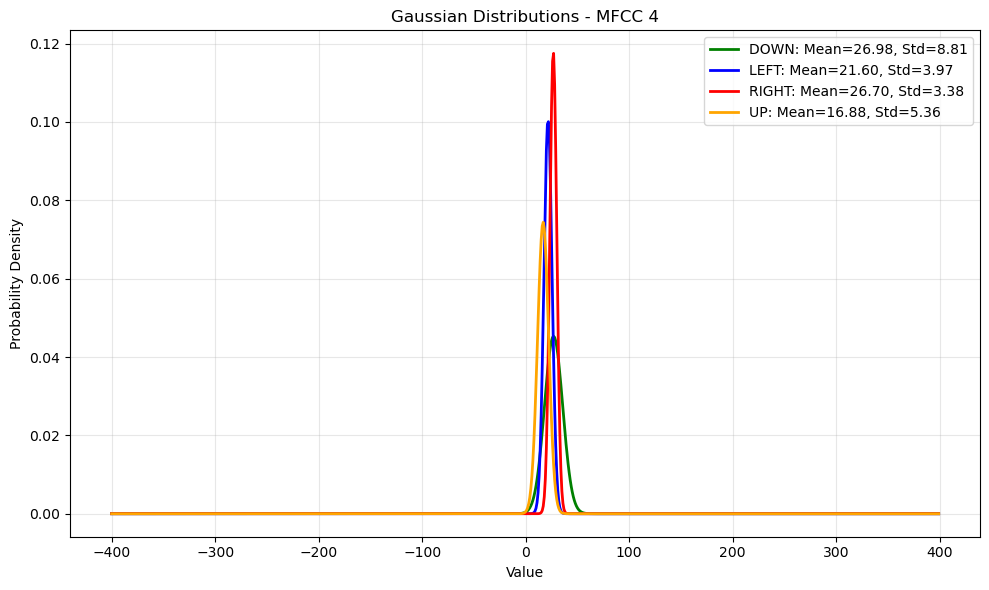

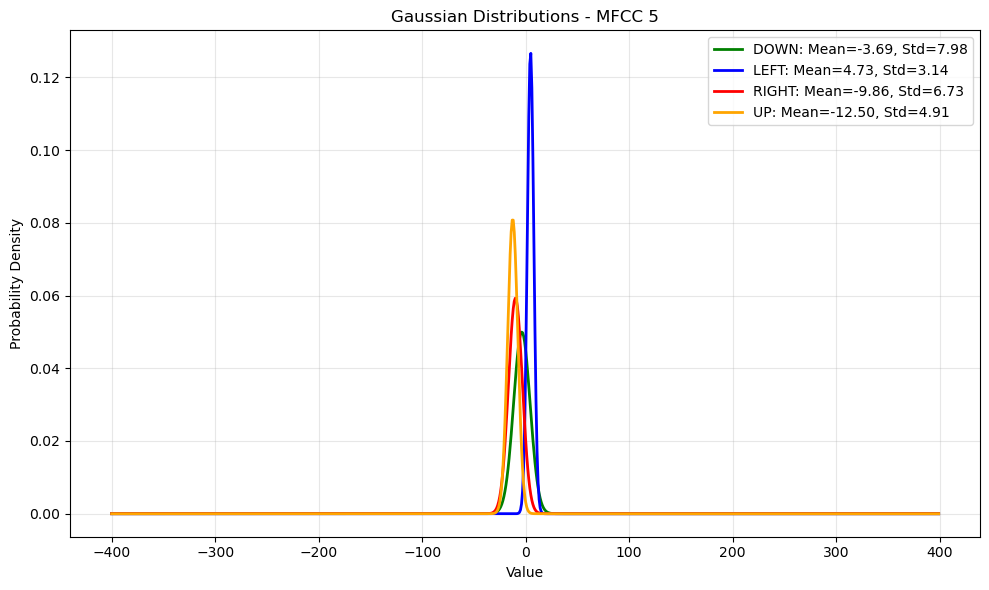

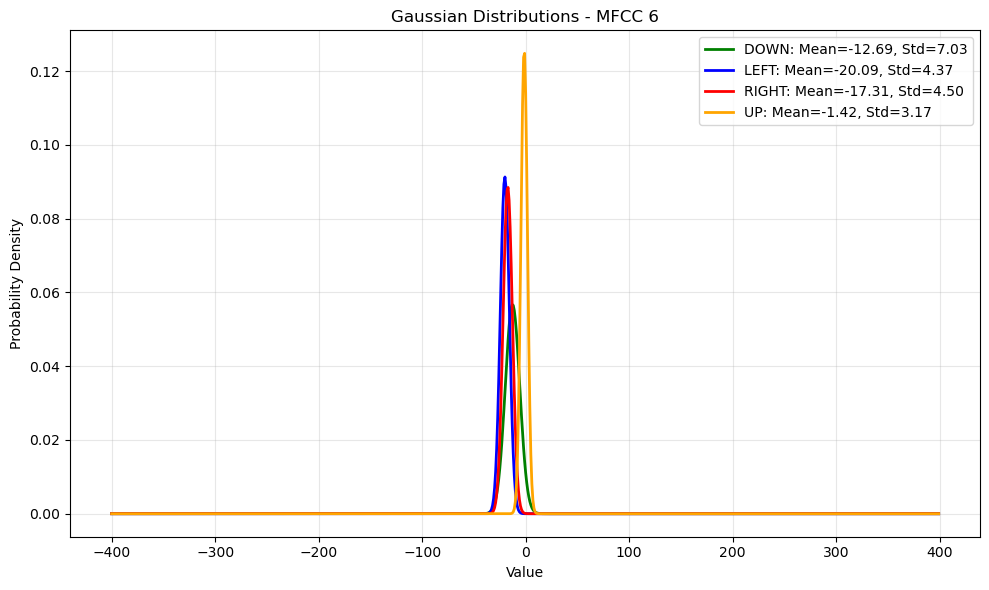

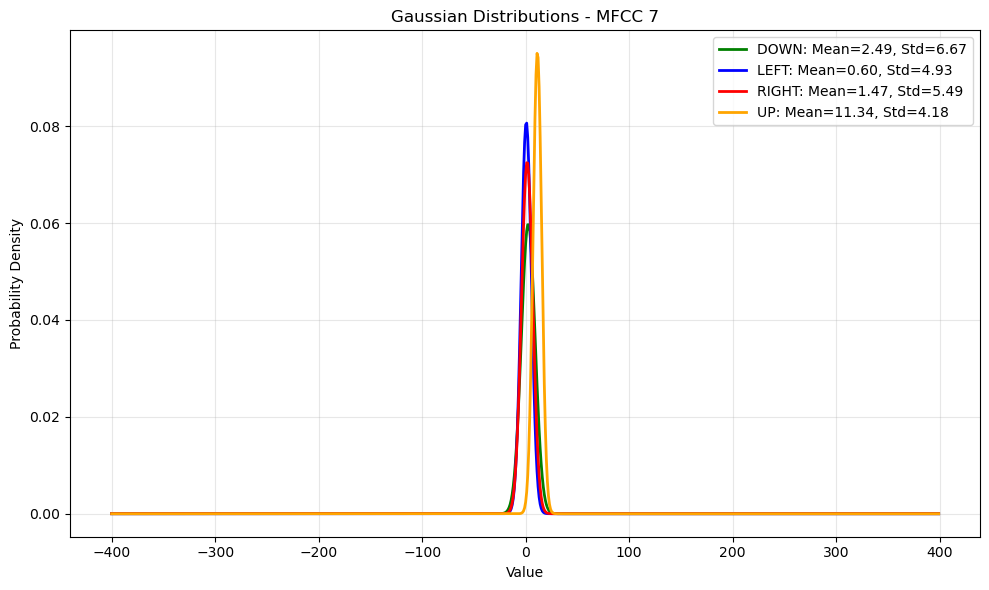

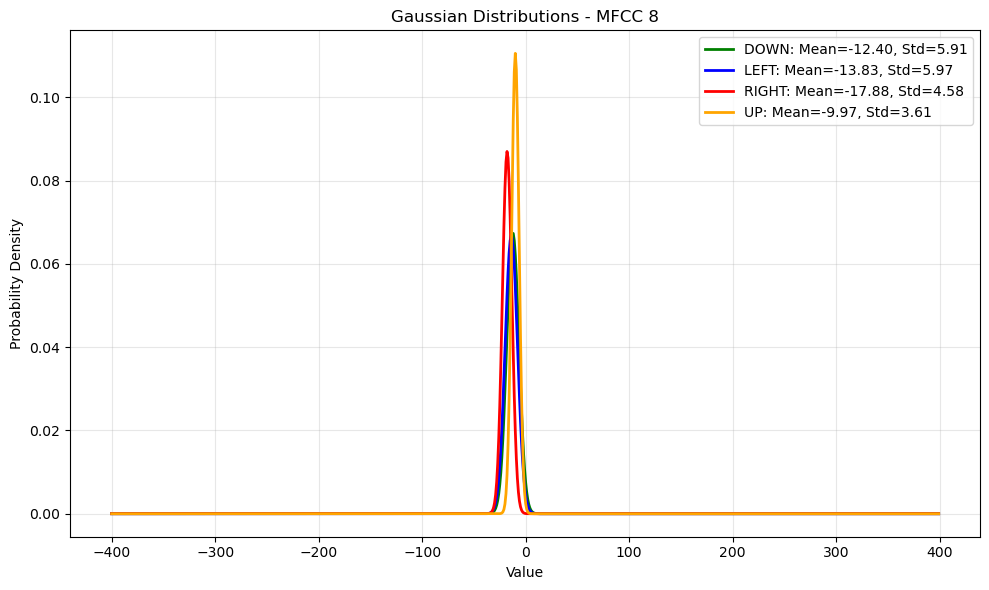

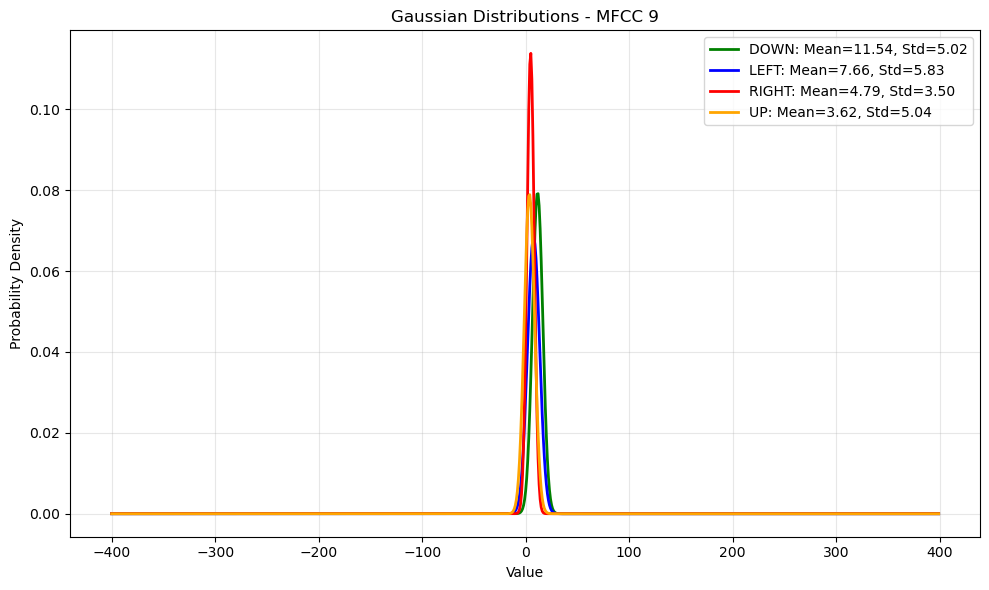

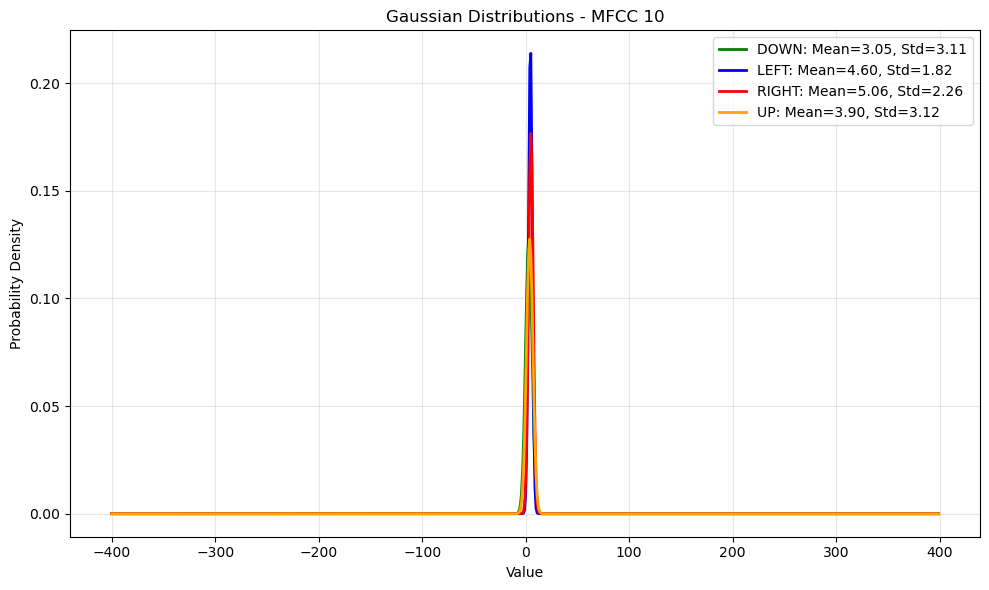

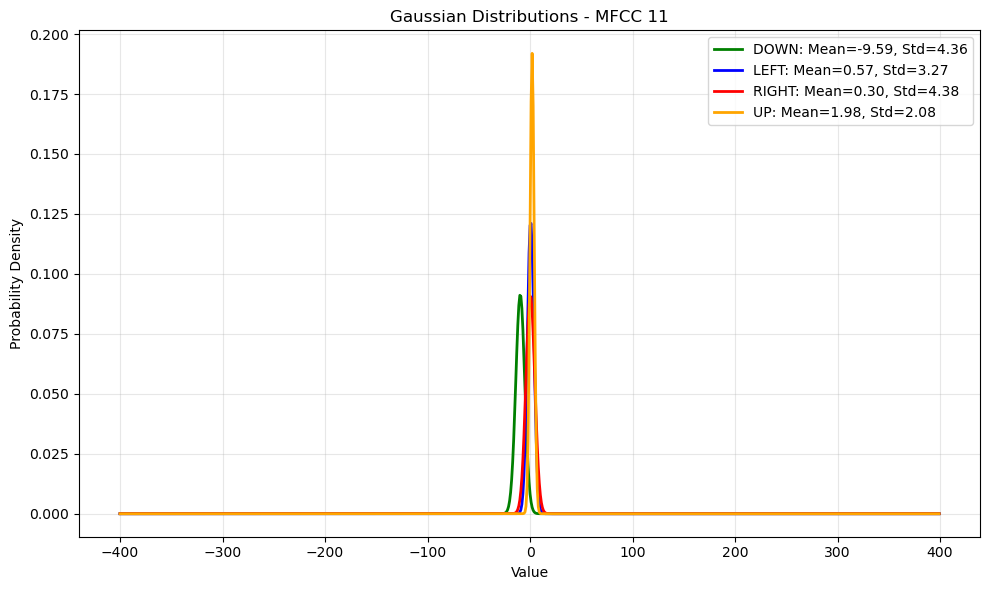

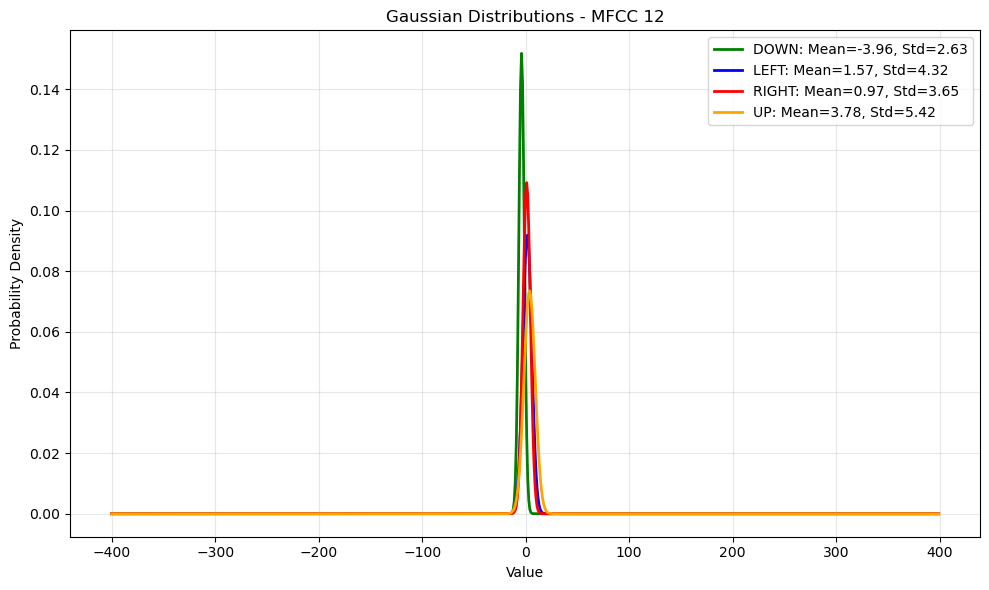

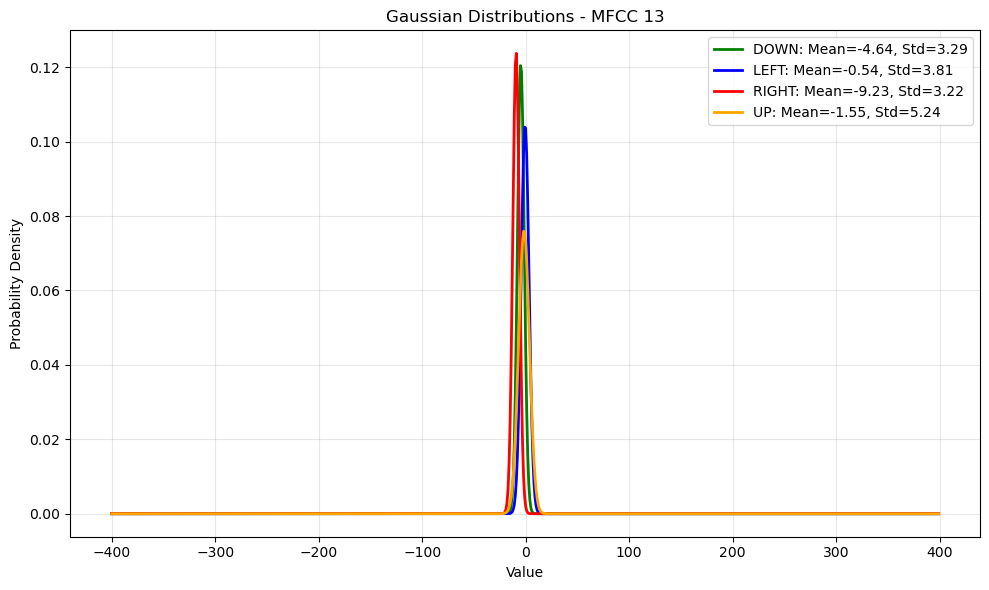

In [14]:
class_labels = {
    'LEFT': 0,
    'RIGHT': 1,
    'DOWN': 2,
    'UP': 3
}

for mfcc_num in range(1, 14):
    x = np.arange(-400, 400, 1)
    plt.figure(figsize=(10, 6))
    
    label_order = ['LEFT', 'RIGHT', 'DOWN', 'UP']
    colors = ['blue', 'red', 'green', 'orange']
    
    for curve in curves:
        feature, cls, mean, std = curve
        if feature == mfcc_num:
            label_idx = list(class_labels.keys()).index(cls) if cls in class_labels else -1
            color = colors[label_idx] if label_idx >= 0 else 'black'
            f = (1/(std*np.sqrt(2*np.pi))*np.exp(-0.5*((x-mean)/std)**2))
            plt.plot(x, f, label=f'{cls}: Mean={mean:.2f}, Std={std:.2f}', color=color, linewidth=2)
    
    plt.xlabel('Value')
    plt.ylabel('Probability Density')
    plt.title(f'Gaussian Distributions - MFCC {mfcc_num}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
means = gnb.theta_  # shape: (n_classes, n_features)
variances = gnb.var_  # shape: (n_classes, n_features)
priors = gnb.class_prior_  # shape: (n_classes,)
class_names = ["LEFT", "RIGHT", "UP", "DOWN"]
print("Means (theta_):")
print(means)

Means (theta_):
[[-27.42860826 131.75670751 -28.92004242  24.67342786  -4.09071253
  -14.00281262   3.80222309 -11.51132341   9.85560954   3.28214467
   -9.32720904  -4.26049085  -3.96933977]
 [-76.70217056 110.70755386 -18.88336978  21.5992775    4.72996681
  -20.09108486   0.60082749 -13.83372459   7.65939493   4.60418839
    0.56920445   1.57341023  -0.53768584]
 [-41.45978355 122.98201534 -35.90479742  28.18591336 -11.09191799
  -16.82007756   1.20560612 -19.26943888   5.30631515   4.40752883
   -0.3142387    0.76636468 -10.42993041]
 [ 41.73615189  79.74625092 -14.5294672   17.47883167 -11.67580509
   -0.61503668   9.70532222  -7.24566545   2.9498028    4.20499477
    0.90567254   2.90074635   0.27725351]]


In [ ]:
NUM_CLASSES = len(class_names)
NUM_MFCC = 13

# Validate dimensions
assert means.shape == (NUM_CLASSES, NUM_MFCC), f"Means shape mismatch: {means.shape}"
assert variances.shape == (NUM_CLASSES, NUM_MFCC), f"Variances shape mismatch: {variances.shape}"
assert priors.shape == (NUM_CLASSES,), f"Priors shape mismatch: {priors.shape}"
assert abs(priors.sum() - 1.0) < 0.01, f"Priors don't sum to 1: {priors.sum()}"